# Simulated Data
### Following https://arxiv.org/pdf/0910.1205, Financial Applications of Random Matrix Theory
### For N stocks and T days
### Randomly generate a covariance matrix of size $N \times N$ 
### and from this the corresponding correlation matrix
### generate un-normalised returns using the covariance matrix, use these to estimate the covariance matrix
### normalise the returns, estimate the correlation matrix from the normalised returns
### Simulate daily returns using this correlation matrix
### Estimate the correlation matrix from the simulated returns
### Compare the estimated correlation matrix $E$ and actual correlation matrix $C$
### Check the claim : $(1.0 - q) * Trace(E^{-1}) = Trace(C^{-1})$

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt

## 1. Generate covariance matrix and (un-normalised) returns. Estimate covariance matrix

Number of stocks : N =  50
Number of days : T =  1000
operator_norm(real_cov) =  0.9884296726401244
frobenius_norm(real_cov) =  3.8015854816109442
operator_norm(S) =  0.9884296726401249
frobenius_norm(S) =  3.801585481610944
basic stats for eig_vals:
shape : (50,)
min : 0.010302651693607123
max : 0.9884296726401249
sum : 22.382611666173954
mean : 0.4476522333234791
std : 0.2977390157174632
Sanity check : operator_norm(Q @ Q.T - identity_N) =  1.9204586753487214e-15
Sanity check : frobenius_norm(Q @ Q.T - identity_N) =  4.954902881485177e-15
Z.shape =  (1000, 50)
R.shape =  (1000, 50)
basic stats for daily returns
shape : (1000, 50)
min : -2.9521450205484836
max : 2.7714600928185646
sum : -154.5361185738674
mean : -0.003090722371477348
std : 0.6709397289073566


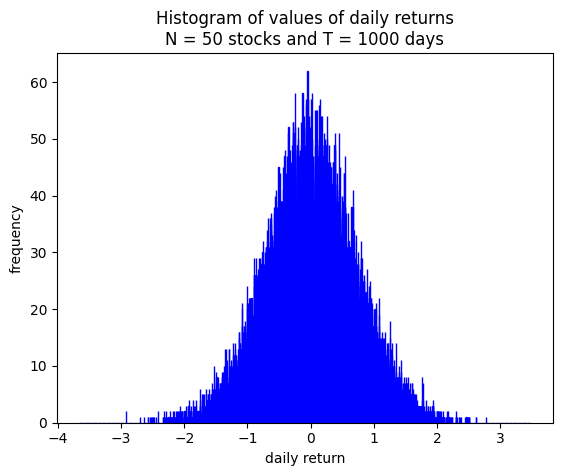

est_cov.shape =  (50, 50)
operator_norm(est_cov) =  1.14164150030423
operator_norm(real_cov) =  0.9884296726401244
operator_norm(real_cov - est_cov) =  0.29374200434598424
frobenius_norm(est_cov) =  3.8813992349150883
frobenius_norm(real_cov) =  3.8015854816109442
frobenius_norm(real_cov - est_cov) =  0.7406908255565682
q =  0.05
Trace(real_cov^{-1}) =  332.3698070208786
Trace(est_cov^{-1}) =  353.3926344470326
Sanity check (1.0 - q) * Trace(est_cov^{-1}) = Trace(real_cov^{-1})
(1.0 - q) * Trace(est_cov^{-1}) =  335.72300272468095 , Trace(real_cov^{-1}) =  332.3698070208786 , error =  0.010038197723491108
operator_norm( (1.0 - q) * est_cov^{-1} ) =  101.27927898885933
operator_norm( real_cov^{-1} ) =  97.06239031845654
Sanity check : operator_norm( (1.0 - q) * est_cov^{-1} - real_cov^{-1} ) = 8.536904850139631
frobenius_norm( (1.0 - q) * est_cov^{-1} ) =  115.14412633498031
frobenius_norm( real_cov^{-1} ) =  110.70114596909556
Sanity check : frobenius_norm( (1.0 - q) * est_cov^{-1} - r

In [16]:

N = 50 # number of stocks
T = 1000 # number of days

print("Number of stocks : N = ", N)
print("Number of days : T = ", T)

real_cov, Q, S, eig_vals = generate_covariance_matrix(N)

if N <= 5:
    print("real_cov = ", real_cov)

print("operator_norm(real_cov) = ", operator_norm(real_cov))
print("frobenius_norm(real_cov) = ", frobenius_norm(real_cov)) 
print("operator_norm(S) = ", operator_norm(S))
print("frobenius_norm(S) = ", frobenius_norm(S))

print("basic stats for eig_vals:")
display_stats(eig_vals)

# N * N identity matrix
identity_N = np.identity(N)

# check that Q is orthogonal
print("Sanity check : operator_norm(Q @ Q.T - identity_N) = ", operator_norm(Q @ Q.T - identity_N))
print("Sanity check : frobenius_norm(Q @ Q.T - identity_N) = ", frobenius_norm(Q @ Q.T - identity_N))

sqrt_eig_vals = this_vec_sqrt(eig_vals)
sqrt_S = np.diag(sqrt_eig_vals)

# generate a random array of size T * N, with independent N(0,1) entries
mean = 0
std_dev = 1
shape = (T,N)
Z = np.random.normal(loc=mean, scale=std_dev, size=shape)
print("Z.shape = ", Z.shape)

# generate the (un-normalised) T * N matrix of random returns
# column i is the returns to stock i
R = Z @ sqrt_S @ Q.T
print("R.shape = ", R.shape)

print("basic stats for daily returns")
display_stats(R)

this_title = "Histogram of values of daily returns\n"
this_title += "N = " + str(N) + " stocks and T = " + str(T) + " days"
plot_histogram(R, x_label = "daily return", y_label = "frequency", hist_title = this_title)

# normalise
X = (1.0 / math.sqrt(T)) * R

# estimate the covariance matrix
est_cov = X.T @ X
print("est_cov.shape = ", est_cov.shape)
print("operator_norm(est_cov) = ", operator_norm(est_cov))
print("operator_norm(real_cov) = ", operator_norm(real_cov))
print("operator_norm(real_cov - est_cov) = ", operator_norm(real_cov - est_cov))
print("frobenius_norm(est_cov) = ", frobenius_norm(est_cov))
print("frobenius_norm(real_cov) = ", frobenius_norm(real_cov))
print("frobenius_norm(real_cov - est_cov) = ", frobenius_norm(real_cov - est_cov))

if N <= 5:
    print("real_cov = ", real_cov)
    print("est_cov = ", est_cov)

# aspect ratio
q = N/T
print("q = ", q)

# sanity check the claim : (1.0 - q) * Trace(est_cov^{-1}) = Trace(real_cov^{-1})
real_cov_inv = np.linalg.inv(real_cov)
trace_real_cov_inv = np.trace(real_cov_inv)
print("Trace(real_cov^{-1}) = ", trace_real_cov_inv)

est_cov_inv = np.linalg.inv(est_cov)
rescale_est_cov_inv = (1.0 - q) * est_cov_inv
trace_est_cov_inv = np.trace(est_cov_inv)
print("Trace(est_cov^{-1}) = ", trace_est_cov_inv)

print("Sanity check (1.0 - q) * Trace(est_cov^{-1}) = Trace(real_cov^{-1})")
lhs = (1.0 - q) * trace_est_cov_inv
rhs = trace_real_cov_inv
print("(1.0 - q) * Trace(est_cov^{-1}) = ", lhs, ", Trace(real_cov^{-1}) = ", rhs, ", error = ", abs(math.log(lhs/rhs)))

print("operator_norm( (1.0 - q) * est_cov^{-1} ) = ", operator_norm(rescale_est_cov_inv))
print("operator_norm( real_cov^{-1} ) = ", operator_norm(real_cov_inv))
print("Sanity check : operator_norm( (1.0 - q) * est_cov^{-1} - real_cov^{-1} ) =", operator_norm(rescale_est_cov_inv - real_cov_inv))

print("frobenius_norm( (1.0 - q) * est_cov^{-1} ) = ", frobenius_norm(rescale_est_cov_inv))
print("frobenius_norm( real_cov^{-1} ) = ", frobenius_norm(real_cov_inv))
print("Sanity check : frobenius_norm( (1.0 - q) * est_cov^{-1} - real_cov^{-1} ) =", frobenius_norm(rescale_est_cov_inv - real_cov_inv))

if N <= 5:
    print("real_cov_inv = ", real_cov_inv)
    print("est_cov_inv = ", est_cov_inv)

# Correlation

(50,)
Basic stats for per-stock volatilities:
shape : (50,)
min : 0.5750019030323333
max : 0.7482643261377099
sum : 33.3676251988243
mean : 0.667352503976486
std : 0.047883909194980624
real_corr :  [[1.         0.06020626 0.13241774 0.10592693 0.02699413]
 [0.06020626 1.         0.02194196 0.03640779 0.11269792]
 [0.13241774 0.02194196 1.         0.00986911 0.04579333]
 [0.10592693 0.03640779 0.00986911 1.         0.0295566 ]
 [0.02699413 0.11269792 0.04579333 0.0295566  1.        ]]
(1000, 50)
(50,)
Basic stats for per stock average returns :
shape : (50,)
min : -0.037780838611965066
max : 0.044605488219423665
sum : -0.15453611857386762
mean : -0.0030907223714773525
std : 0.020514575754968633
sanity check - should be zeros :  [ 7.43849426e-15  9.21485110e-15  1.36224365e-13 -2.07889261e-14
 -1.64868119e-14]
sanity check - should be zero :  4.662329906120028e-26
Basic stats for demeaned_daily_returns : 
shape : (1000, 50)
min : -2.974756010388554
max : 2.726854604599141
sum : 2.4158453

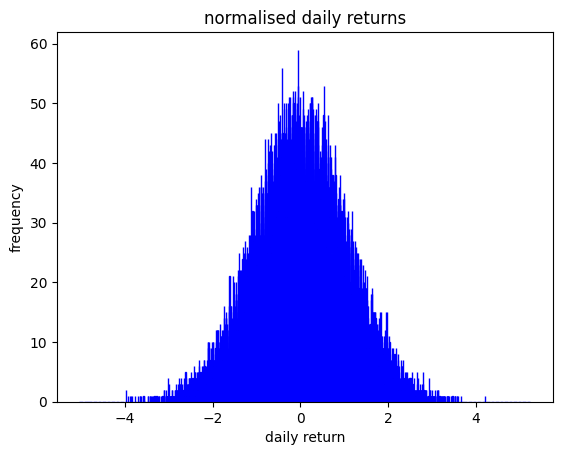

est_corr =  [[1.         0.02584895 0.10712465]
 [0.02584895 1.         0.00354384]
 [0.10712465 0.00354384 1.        ]]
real_corr =  [[1.         0.06020626 0.13241774]
 [0.06020626 1.         0.02194196]
 [0.13241774 0.02194196 1.        ]]
est_corr.shape =  (50, 50)
operator_norm(est_corr) =  2.554067096474419
operator_norm(real_corr) =  2.2255521874617252
operator_norm(real_corr - est_corr) =  0.6144556384460905
frobenius_norm(est_corr) =  8.577449342824004
frobenius_norm(real_corr) =  8.452494199330737
frobenius_norm(real_corr - est_corr) =  1.6132986013197983
q =  0.05
Trace(real_corr^{-1}) =  145.7834726813457
Trace(est_corr^{-1}) =  155.5548098971868
Sanity check (1.0 - q) * Trace(est_corr^{-1}) = Trace(real_corr^{-1})
(1.0 - q) * Trace(est_corr^{-1}) =  147.77706940232744 , Trace(real_corr^{-1}) =  145.7834726813457 , error =  0.013582393295758602
operator_norm( (1.0 - q) * est_corr^{-1} ) =  44.827160434949235
operator_norm( real_corr^{-1} ) =  42.97953466070241
Sanity check 

In [20]:
# get the per-stock variances as the diagonal entries of the (real) covariance matrix
per_stock_variances = np.diagonal(real_cov)
print(per_stock_variances.shape)

# the per-stock volatilities are the sqrt of the variances
per_stock_vols = this_vec_sqrt(per_stock_variances)
print("Basic stats for per-stock volatilities:")
display_stats(per_stock_vols)

# we want to rescale by the inverse volatilities
inv_vols = this_vec_one_divided_by(per_stock_vols)
scaling_factor = np.diag(inv_vols)
k = 5
#print(scaling_factor.shape)
#print("inv_vols scaling factor : ", scaling_factor[0:k,0:k])

# rescale the (real) covariance matrix to get the (real) correlation matrix
real_corr = scaling_factor @ real_cov @ scaling_factor
print("real_corr : ", real_corr[0:k,0:k])

# Normalise the daily returns.
# Note : we're doing this in the simplest possible fashion
# if we were using real data we would need to care about lookahead
un_normalised_daily_returns = R
print(un_normalised_daily_returns.shape)
per_stock_avg_return = (1.0 / T) * np.sum(un_normalised_daily_returns, axis=0)
print(per_stock_avg_return.shape)
print("Basic stats for per stock average returns :")
display_stats(per_stock_avg_return)

# reshape to T * N
xx = np.ones((T,N)) @ np.diag(per_stock_avg_return)
#print(xx.shape)
#print(xx[0:k,0:k])
demeaned_daily_returns = un_normalised_daily_returns - xx
sanity_check = np.sum(demeaned_daily_returns, axis=0)
print("sanity check - should be zeros : ", sanity_check[0:k])
print("sanity check - should be zero : ", np.sum(sanity_check.T @ sanity_check))

print("Basic stats for demeaned_daily_returns : ")
display_stats(demeaned_daily_returns)

# recalculate per stock variances using these demeaned daily returns
per_stock_variances = np.zeros(N)
for i in range(0,N):
    per_stock_returns = demeaned_daily_returns[:,i]
    per_stock_variances[i] = (1.0 / T) * np.sum(per_stock_returns.T @ per_stock_returns)
per_stock_vols = this_vec_sqrt(per_stock_variances)
inv_vols = this_vec_one_divided_by(per_stock_vols)

normalised_daily_returns = demeaned_daily_returns @ np.diag(inv_vols)
print("Basic stats for normalised_daily_returns : ")
display_stats(normalised_daily_returns)
plot_histogram(normalised_daily_returns, x_label = "daily return", 
                   y_label = "frequency",
                   hist_title = "normalised daily returns")

#estimate the correlation matrix
est_corr = (1.0 / T) * (normalised_daily_returns.T @ normalised_daily_returns)
k = 3
#print(est_corr.shape)
print("est_corr = ", est_corr[0:k,0:k])
print("real_corr = ", real_corr[0:k,0:k])

print("est_corr.shape = ", est_corr.shape)
print("operator_norm(est_corr) = ", operator_norm(est_corr))
print("operator_norm(real_corr) = ", operator_norm(real_corr))
print("operator_norm(real_corr - est_corr) = ", operator_norm(real_corr - est_corr))
print("frobenius_norm(est_corr) = ", frobenius_norm(est_corr))
print("frobenius_norm(real_corr) = ", frobenius_norm(real_corr))
print("frobenius_norm(real_corr - est_corr) = ", frobenius_norm(real_corr - est_corr))

if N <= 5:
    print("real_corr = ", real_corr)
    print("est_corr = ", est_corr)

# aspect ratio
q = N/T
print("q = ", q)

# sanity check the claim : (1.0 - q) * Trace(est_corr^{-1}) = Trace(real_corr^{-1})
real_corr_inv = np.linalg.inv(real_corr)
trace_real_corr_inv = np.trace(real_corr_inv)
print("Trace(real_corr^{-1}) = ", trace_real_corr_inv)

est_corr_inv = np.linalg.inv(est_corr)
rescale_est_corr_inv = (1.0 - q) * est_corr_inv
trace_est_corr_inv = np.trace(est_corr_inv)
print("Trace(est_corr^{-1}) = ", trace_est_corr_inv)

print("Sanity check (1.0 - q) * Trace(est_corr^{-1}) = Trace(real_corr^{-1})")
lhs = (1.0 - q) * trace_est_corr_inv
rhs = trace_real_corr_inv
print("(1.0 - q) * Trace(est_corr^{-1}) = ", lhs, ", Trace(real_corr^{-1}) = ", rhs, ", error = ", abs(math.log(lhs/rhs)))

print("operator_norm( (1.0 - q) * est_corr^{-1} ) = ", operator_norm(rescale_est_corr_inv))
print("operator_norm( real_corr^{-1} ) = ", operator_norm(real_corr_inv))
print("Sanity check : operator_norm( (1.0 - q) * est_corr^{-1} - real_corr^{-1} ) =", operator_norm(rescale_est_corr_inv - real_corr_inv))

print("frobenius_norm( (1.0 - q) * est_corr^{-1} ) = ", frobenius_norm(rescale_est_corr_inv))
print("frobenius_norm( real_corr^{-1} ) = ", frobenius_norm(real_corr_inv))
print("Sanity check : frobenius_norm( (1.0 - q) * est_corr^{-1} - real_corr^{-1} ) =", frobenius_norm(rescale_est_corr_inv - real_corr_inv))

if N <= 5:
    print("real_corr_inv = ", real_corr_inv)
    print("est_corr_inv = ", est_corr_inv)




# ** OLD **

In [14]:
N = 2 # number of stocks
T = 250 # number of days

print("Number of stocks : N = ", N)
print("Number of days : T = ", T)

C = generate_correlation_matrix(N)
print(C)

print("operator_norm(C) = ", operator_norm(C))
print("frobenius_norm(C) = ", frobenius_norm(C)) 
#print("operator_norm(S) = ", operator_norm(S))
#print("frobenius_norm(S) = ", frobenius_norm(S))

correlation_vals = np.zeros(int((N*N - N)/2))
count=0
for i in range(0,N):
    for j in range(i+1,N):
        correlation_vals[count] = C[i,j]
        count +=1
print("basic stats for correlation matrix:")
display_stats(correlation_vals)

# generate a random array of size T * N, with independent N(0,1) entries
mean = 0
std_dev = 1
shape = (T,N)
Z = np.random.normal(loc=mean, scale=std_dev, size=shape)
print("Z.shape = ", Z.shape)

un_normalised_returns = Z @ C # T * N
print("basic stats for un-normalised returns")
display_stats(un_normalised_returns)

# normalise so that returns have mean 0 and stddev 1
per_stock_variance = (1.0 / T) * np.diagonal(un_normalised_returns.T @ un_normalised_returns)
per_stock_vols = this_vec_sqrt(per_stock_variance)
per_stock_scaling_factors =  np.diag(this_vec_one_divided_by(per_stock_vols))
normalised_returns = un_normalised_returns @ per_stock_scaling_factors
print(normalised_returns.shape)
print("basic stats for normalised returns")
display_stats(normalised_returns)

this_title = "Histogram of values of normalised daily returns\n"
this_title += "N = " + str(N) + " stocks and T = " + str(T) + " days"
#plot_histogram(normalised_returns, x_label = "normalised daily return", y_label = "frequency", hist_title = this_title)

X = (1.0 / math.sqrt(T)) * normalised_returns

# Pearson estimator for the correlation matrix
E = X.T @ X
print(E.shape)
print("E.shape = ", E.shape)
print("operator_norm(E) = ", operator_norm(E))
print("operator_norm(C) = ", operator_norm(C))
print("operator_norm(E - C) = ", operator_norm(E - C))
print("frobenius_norm(E) = ", frobenius_norm(E))
print("frobenius_norm(C) = ", frobenius_norm(C))
print("frobenius_norm(E - C) = ", frobenius_norm(E - C))

# aspect ratio
q = N/T
print("q = ", q)

# sanity check the claim : (1.0 - q) * Trace(E^{-1}) = Trace(C^{-1})
C_inv = np.linalg.inv(C)
trace_C_inv = np.trace(C_inv)
print("Trace(C^{-1}) = ", trace_C_inv)

E_inv = np.linalg.inv(E)
rescale_E_inv = (1.0 - q) * E_inv
trace_E_inv = np.trace(E_inv)
print("Trace(E^{-1}) = ", trace_E_inv)

print("Sanity check (1.0 - q) * Trace(E^{-1}) = Trace(C^{-1})")
lhs = (1.0 - q) * trace_E_inv
rhs = trace_C_inv
print("(1.0 - q) * Trace(E^{-1}) = ", lhs, ", Trace(C^{-1}) = ", rhs, ", error = ", abs(math.log(lhs/rhs)))

print("operator_norm( (1.0 - q) * E^{-1} ) = ", operator_norm(rescale_E_inv))
print("operator_norm( C^{-1} ) = ", operator_norm(C_inv))
print("Sanity check : operator_norm( (1.0 - q) * E^{-1} - C^{-1} ) =", operator_norm(rescale_E_inv - C_inv))

print("frobenius_norm( (1.0 - q) * E^{-1} ) = ", frobenius_norm(rescale_E_inv))
print("frobenius_norm( C^{-1} ) = ", frobenius_norm(C_inv))
print("Sanity check : frobenius_norm( (1.0 - q) * E^{-1} - C^{-1} ) =", frobenius_norm(rescale_E_inv - C_inv))





Number of stocks : N =  2
Number of days : T =  250
[[ 1.         -0.21961345]
 [-0.21961345  1.        ]]
operator_norm(C) =  1.2196134527893128
frobenius_norm(C) =  1.4479157908152283
basic stats for correlation matrix:
shape : (1,)
min : -0.2196134527893125
max : -0.2196134527893125
sum : -0.2196134527893125
mean : -0.2196134527893125
std : 0.0
Z.shape =  (250, 2)
basic stats for un-normalised returns
shape : (250, 2)
min : -2.886209167081632
max : 2.59473184043799
sum : -6.304681450704431
mean : -0.012609362901408861
std : 1.0296696231262101
(250, 2)
basic stats for normalised returns
shape : (250, 2)
min : -2.9076818355007745
max : 2.614035991045568
sum : -7.372639249787103
mean : -0.014745278499574207
std : 0.9998912824712343
(2, 2)
E.shape =  (2, 2)
operator_norm(E) =  1.419911148601617
operator_norm(C) =  1.2196134527893128
operator_norm(E - C) =  0.20029769581230503
frobenius_norm(E) =  1.5338353058395344
frobenius_norm(C) =  1.4479157908152283
frobenius_norm(E - C) =  0.28326

# Covariance

Number of stocks : N =  5
Number of days : T =  200
operator_norm(C) =  0.8574309484636117
frobenius_norm(C) =  1.387779989800347
operator_norm(S) =  0.8574309484636113
frobenius_norm(S) =  1.3877799898003464
basic stats for eig_vals:
shape : (5,)
min : 0.21990233523275782
max : 0.8574309484636113
sum : 2.835103888917623
mean : 0.5670207777835247
std : 0.25233726950218166
Sanity check : operator_norm(Q @ Q.T - identity_N) =  1.2241020635298553e-15
Sanity check : frobenius_norm(Q @ Q.T - identity_N) =  1.4881738405137401e-15
Z.shape =  (200, 5)
R.shape =  (200, 5)
basic stats for daily returns
shape : (200, 5)
min : -2.112540765911328
max : 2.348808082875643
sum : 15.116066244457745
mean : 0.015116066244457745
std : 0.7483658212073113


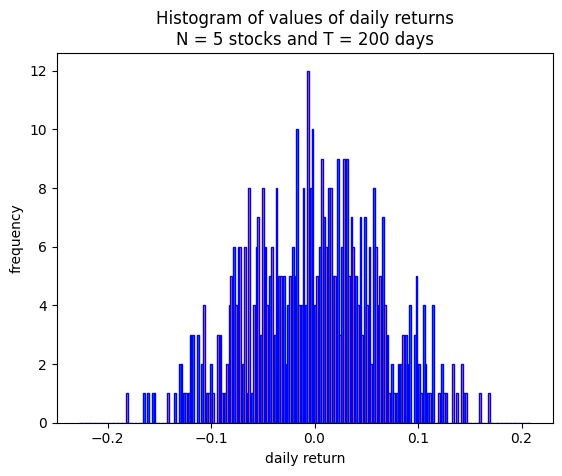

E.shape =  (5, 5)
operator_norm(E) =  0.8500472742890967
operator_norm(C) =  0.8574309484636117
frobenius_norm(E) =  1.3781295009073253
frobenius_norm(C) =  1.387779989800347
q =  0.025
Trace(C^{-1}) =  11.537401444662624
Trace(E^{-1}) =  11.72974209718782
Sanity check (1.0 - q) * Trace(E^{-1}) = Trace(C^{-1})
(1.0 - q) * Trace(E^{-1}) =  11.436498544758125 , Trace(C^{-1}) =  11.537401444662624 , error =  0.00878418977818389
operator_norm( (1.0 - q) * E^{-1} ) =  4.270108639571826
operator_norm( C^{-1} ) =  4.547473308737449
Sanity check : operator_norm( (1.0 - q) * E^{-1} - C^{-1} ) = 0.4913315478479033
frobenius_norm( (1.0 - q) * E^{-1} ) =  5.81810448215613
frobenius_norm( C^{-1} ) =  5.90999414077988
Sanity check : frobenius_norm( (1.0 - q) * E^{-1} - C^{-1} ) = 0.6458695121910872


In [15]:
N = 5 # number of stocks
T = 200 # number of days

print("Number of stocks : N = ", N)
print("Number of days : T = ", T)

C, Q, S, eig_vals = generate_covariance_matrix(N)

print("operator_norm(C) = ", operator_norm(C))
print("frobenius_norm(C) = ", frobenius_norm(C)) 
print("operator_norm(S) = ", operator_norm(S))
print("frobenius_norm(S) = ", frobenius_norm(S))

print("basic stats for eig_vals:")
display_stats(eig_vals)

# N * N identity matrix
identity_N = np.identity(N)

# check that Q is orthogonal
print("Sanity check : operator_norm(Q @ Q.T - identity_N) = ", operator_norm(Q @ Q.T - identity_N))
print("Sanity check : frobenius_norm(Q @ Q.T - identity_N) = ", frobenius_norm(Q @ Q.T - identity_N))

sqrt_eig_vals = this_vec_sqrt(eig_vals)
sqrt_S = np.diag(sqrt_eig_vals)

# generate a random array of size T * N, with independent N(0,1) entries
mean = 0
std_dev = 1
shape = (T,N)
Z = np.random.normal(loc=mean, scale=std_dev, size=shape)
print("Z.shape = ", Z.shape)

# generate the (un-normalised) T * N matrix of random returns
# column i is the returns to stock i
R = Z @ sqrt_S @ Q.T
print("R.shape = ", R.shape)

print("basic stats for daily returns")
display_stats(R)

this_title = "Histogram of values of daily returns\n"
this_title += "N = " + str(N) + " stocks and T = " + str(T) + " days"
plot_histogram(X, x_label = "daily return", y_label = "frequency", hist_title = this_title)

# normalise
X = (1.0 / math.sqrt(T)) * R

# estimate the covariance matrix
E = X.T @ X
print("E.shape = ", E.shape)
print("operator_norm(E) = ", operator_norm(E))
print("operator_norm(C) = ", operator_norm(C))
print("frobenius_norm(E) = ", frobenius_norm(E))
print("frobenius_norm(C) = ", frobenius_norm(C))

# aspect ratio
q = N/T
print("q = ", q)

# sanity check the claim : (1.0 - q) * Trace(E^{-1}) = Trace(C^{-1})
C_inv = np.linalg.inv(C)
trace_C_inv = np.trace(C_inv)
print("Trace(C^{-1}) = ", trace_C_inv)

E_inv = np.linalg.inv(E)
rescale_E_inv = (1.0 - q) * E_inv
trace_E_inv = np.trace(E_inv)
print("Trace(E^{-1}) = ", trace_E_inv)

print("Sanity check (1.0 - q) * Trace(E^{-1}) = Trace(C^{-1})")
lhs = (1.0 - q) * trace_E_inv
rhs = trace_C_inv
print("(1.0 - q) * Trace(E^{-1}) = ", lhs, ", Trace(C^{-1}) = ", rhs, ", error = ", abs(math.log(lhs/rhs)))

print("operator_norm( (1.0 - q) * E^{-1} ) = ", operator_norm(rescale_E_inv))
print("operator_norm( C^{-1} ) = ", operator_norm(C_inv))
print("Sanity check : operator_norm( (1.0 - q) * E^{-1} - C^{-1} ) =", operator_norm(rescale_E_inv - C_inv))

print("frobenius_norm( (1.0 - q) * E^{-1} ) = ", frobenius_norm(rescale_E_inv))
print("frobenius_norm( C^{-1} ) = ", frobenius_norm(C_inv))
print("Sanity check : frobenius_norm( (1.0 - q) * E^{-1} - C^{-1} ) =", frobenius_norm(rescale_E_inv - C_inv))

In [13]:
# apply sqrt to an array by vectorisation
def this_sqrt(x):
  return math.sqrt(max(x,0.0))

# Apply the function using np.vectorize
this_vec_sqrt = np.vectorize(this_sqrt)

In [12]:
def this_one_divided_by(x):
    return 1.0 / x

# Apply the function using np.vectorize
this_vec_one_divided_by = np.vectorize(this_one_divided_by)

In [11]:
def generate_correlation_matrix(N : int) -> tuple:

    # first of all generate a covariance matrix
    covariance_matrix, Q, S, eig_vals = generate_covariance_matrix(N)
    #print(covariance_matrix)

    # get the variances
    per_stock_vars = np.diagonal(covariance_matrix)
    #print(per_stock_vars)

    # get the volatilities
    per_stock_vols = this_vec_sqrt(per_stock_vars)
    #print(per_stock_vols)

    # get the inverse volatilities
    inv_vols = np.diag(this_vec_one_divided_by(per_stock_vols))
    #print(inv_vols)

    # now define the correlation matrix
    C = inv_vols @ covariance_matrix @ inv_vols
    
    return C

In [10]:
def generate_covariance_matrix(N : int, min_eig_val : float = 0.001) -> tuple:

    # generate an orthogonal N * N matrix
    Q = generate_orthogonal_matrix(N)

    # generate non-negative eigenvalues 
    # drawn independently from a uniform U[min_eig_val,1] distribution
    # we use [min_eig_val, 1.0] to prevent blow-ups for C^{-1}
    eig_vals = np.random.uniform(low = min_eig_val, high = 1, size = N) # generate non-negative

    # define the diagonal matrix S
    S = np.diag(eig_vals)

    # generate the covariance matrix
    covariance_matrix = Q @ S @ Q.T

    return covariance_matrix, Q, S, eig_vals

In [9]:
def generate_orthogonal_matrix(N : int) -> np.ndarray:
  """
  generate an orthogonal matrix of dimension N, using the QR decomposition. 
  """
  
  H = np.random.randn(N, N)
  Q, R = np.linalg.qr(H)
  Q *= np.sign(np.diag(R)) # Ensure positive diagonal
  return Q

In [8]:
def operator_norm(A : np.ndarray) -> float:
    """
    calculate the operator norm of an N * N matrix A
    as sqrt(lambda_max)
    where lambda_max is the largest (most positive) eigenvalue of A.T @ A
    """

    # calculate A.T @ A
    ATA = A.T @ A

    # calculate the eignevalues and eigenvectors
    eig_vals, eig_vecs = np.linalg.eig(ATA)

    # get the max eigenvalue
    lambda_max = np.max(eig_vals)

    # calculate the operator norm
    operator_norm = math.sqrt(lambda_max)

    return operator_norm

In [7]:
def frobenius_norm(A : np.ndarray) -> float:
    """
    calculate the Frobenius norm of a matrix A
    as sqrt(Trace(A.T @ A))
    """
    # calculate A.T @ A
    ATA = A.T @ A

    # calculate the trace
    trATA = np.trace(ATA)

    # calculate the frobenius norm as the sqrt of the trace
    frobenius_norm = math.sqrt(trATA)

    return frobenius_norm

In [6]:
def display_stats(this_array : np.ndarray):
    """
    print basic stats for a numpy array
    """
    
    print("shape :", this_array.shape)
    print("min :", np.min(this_array))
    print("max :", np.max(this_array))
    print("sum :", np.sum(this_array))
    print("mean :", np.mean(this_array))
    print("std :", np.std(this_array))
    return

In [5]:
def plot_histogram(this_array : np.ndarray,  
                   x_label : str = "x_label", 
                   y_label : str = "y_label",
                   hist_title : str = "hist_title",
                   num_bins : int = 100,
                   rescale_factor : float = 1.0, 
                   verbose : bool = False
                  ):

    """
    plot a histogram of the values of a numpy array
    """
    
    custom_bins = []
    this_min = np.min(this_array)
    this_max = np.max(this_array)
    this_mid = 0.5 * (this_min + this_max)
    min_value = this_mid + 1.25 * rescale_factor * (this_min - this_mid)
    max_value = this_mid + 1.25 * rescale_factor * (this_max - this_mid)
    step_size = (max_value - min_value) / num_bins
    for i in range(num_bins + 1):
        custom_bins.append(min_value + i * step_size)
    
    # Compute histogram with custom bins
    hist, bin_edges = np.histogram(this_array, bins=custom_bins)

    if verbose:
        print("Histogram counts:", hist)

    plt.hist(this_array, bins=custom_bins, edgecolor='blue')
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(hist_title)
    plt.show()